In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import json

with open("../students_weights/encoder_train/distillation_summary.json", "r") as f:
    data = json.load(f)

resnet_students = pd.DataFrame([d for d in data if d["teacher"] == "resnet"])
convnext_students = pd.DataFrame([d for d in data if d["teacher"] == "convnext"])
vgg_students = pd.DataFrame([d for d in data if d["teacher"] == "vgg"])
vgg_students


,id,teacher,teacher_dim,n_convs,trainable_params,best_val_mse,weights
0,arch1_3conv_narrow__vgg_td512,vgg,512,3,77877,0.001175,C:\Estudos\Unicamp\9_semestre\projeto_dupla_mc...
1,arch2_3conv__vgg_td512,vgg,512,3,182341,0.001076,C:\Estudos\Unicamp\9_semestre\projeto_dupla_mc...
2,arch3_4conv_narrow__vgg_td512,vgg,512,4,543301,0.000967,C:\Estudos\Unicamp\9_semestre\projeto_dupla_mc...
3,arch4_4conv__vgg_td512,vgg,512,4,1480549,0.000908,C:\Estudos\Unicamp\9_semestre\projeto_dupla_mc...
4,arch5_5conv__vgg_td512,vgg,512,5,2431589,0.000858,C:\Estudos\Unicamp\9_semestre\projeto_dupla_mc...
5,arch6_6conv_largest__vgg_td512,vgg,512,6,2579301,0.000841,C:\Estudos\Unicamp\9_semestre\projeto_dupla_mc...


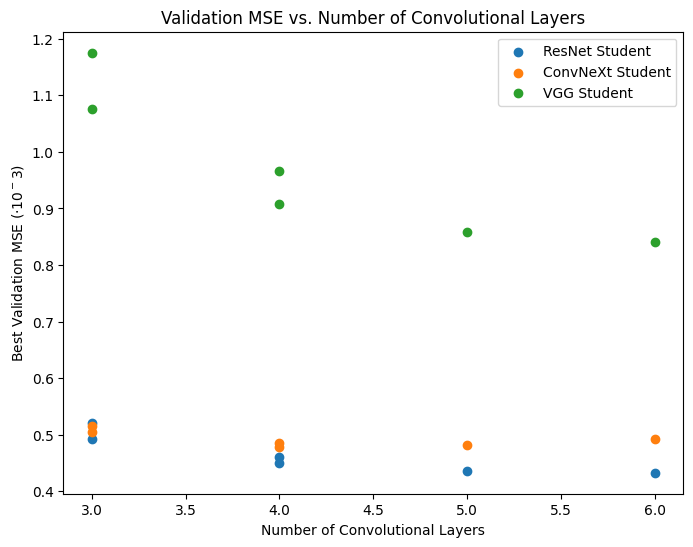

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(resnet_students["n_convs"], resnet_students["best_val_mse"]*1e3, label="ResNet Student", marker="o")
plt.scatter(convnext_students["n_convs"], convnext_students["best_val_mse"]*1e3, label="ConvNeXt Student", marker="o")
plt.scatter(vgg_students["n_convs"], vgg_students["best_val_mse"]*1e3, label="VGG Student", marker="o")
plt.xlabel("Number of Convolutional Layers")
plt.ylabel("Best Validation MSE ($ \\cdot 10^-3$)")
plt.title("Validation MSE vs. Number of Convolutional Layers")
plt.legend()
plt.show()

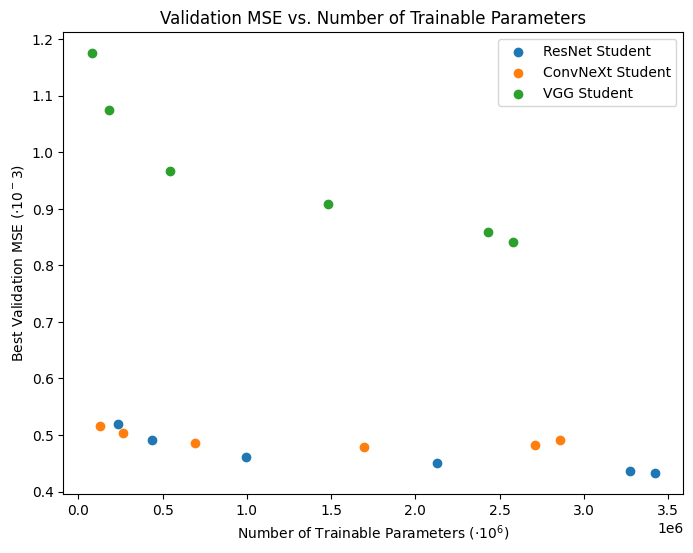

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(resnet_students["trainable_params"], resnet_students["best_val_mse"]*1e3, label="ResNet Student", marker="o")
plt.scatter(convnext_students["trainable_params"], convnext_students["best_val_mse"]*1e3, label="ConvNeXt Student", marker="o")
plt.scatter(vgg_students["trainable_params"], vgg_students["best_val_mse"]*1e3, label="VGG Student", marker="o")
plt.xlabel("Number of Trainable Parameters ($\\cdot10^6$)")
plt.ylabel("Best Validation MSE ($ \\cdot 10^-3$)")
plt.title("Validation MSE vs. Number of Trainable Parameters")
plt.legend()
plt.show()

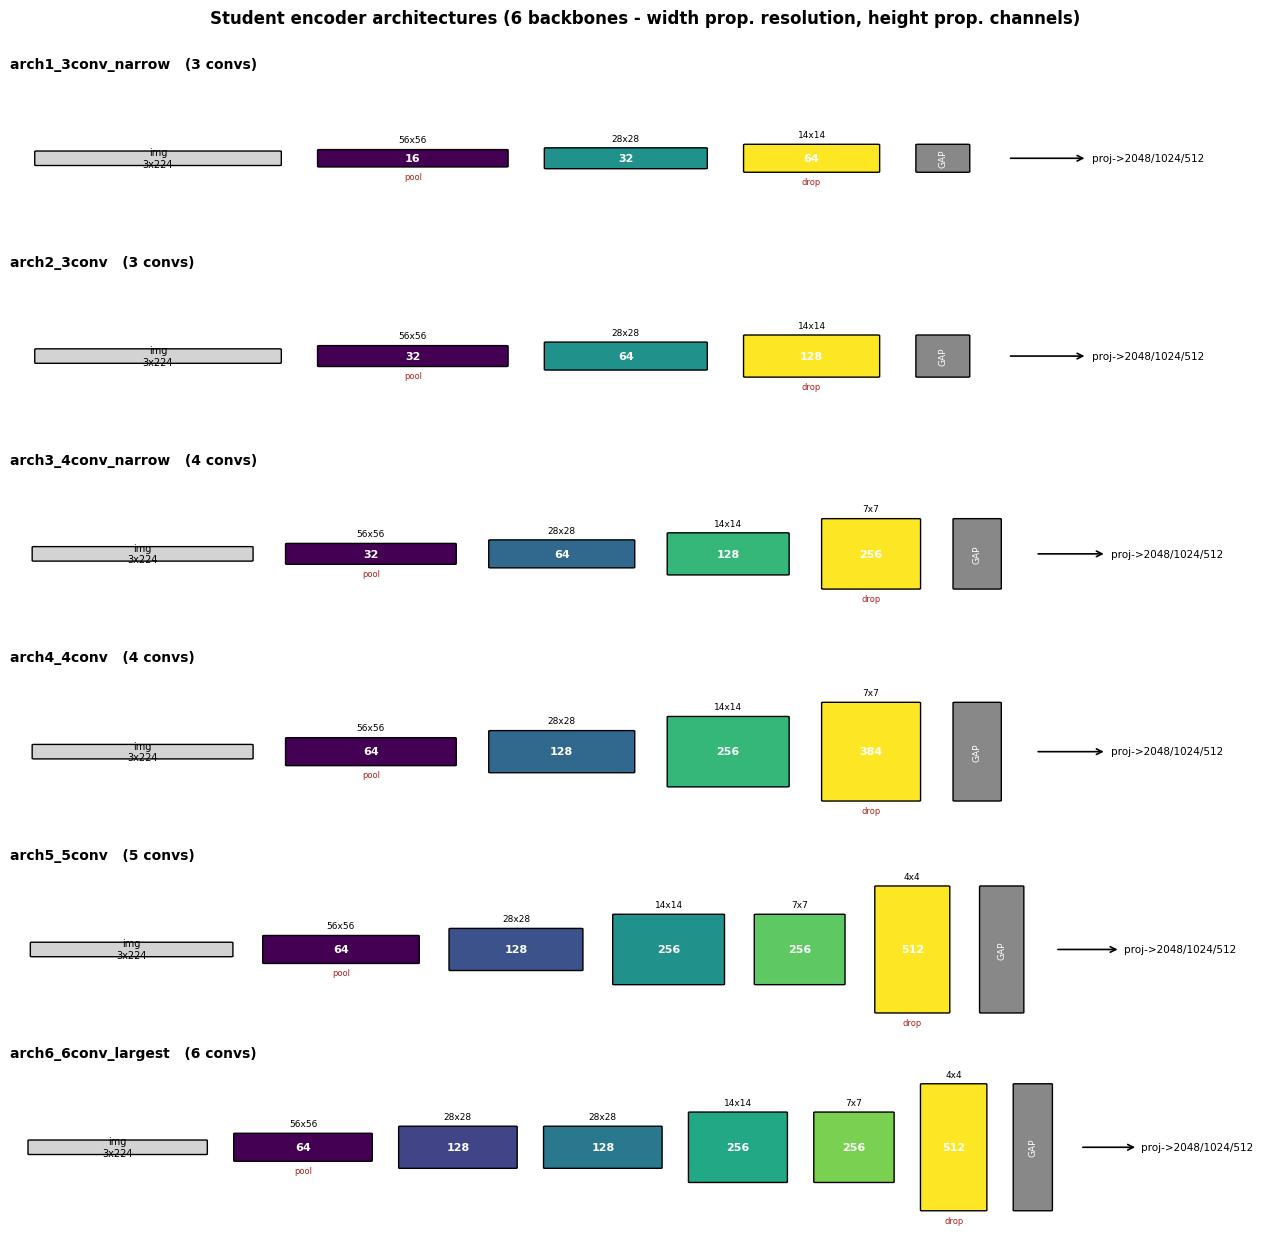

In [32]:
import math
from matplotlib.patches import FancyBboxPatch

INPUT_SIZE = 224

with open("../src/phase2/random_students.json", "r") as f:
    students = json.load(f)


def conv_out(size, kernel, stride, padding):
    return (size + 2 * padding - kernel) // stride + 1


def parse_arch(layers):
    """Per-conv-block info: channels, resulting spatial size, pool, dropout."""
    size = INPUT_SIZE
    blocks = []
    for block in layers:
        for name, attributes in block.items():
            if name in ("project", "classifier"):
                continue
            conv = next((a for a in attributes if a["type"] == "conv2d"), None)
            if conv is None:
                continue
            size = conv_out(size, conv["kernel_size"], conv["stride"], conv["padding"])
            has_pool = False
            for a in attributes:
                if a["type"] == "MaxPool2d":
                    size = conv_out(size, a["kernel_size"], a["stride"], a["padding"])
                    has_pool = True
            blocks.append({
                "out_channels": conv["out_channels"],
                "size": size,
                "maxpool": has_pool,
                "dropout": any(a["type"] == "Dropout" for a in attributes),
            })
    return blocks


width_of = lambda s: 0.25 + 0.32 * math.log2(s + 1)   # width  proportional to resolution
height_of = lambda c: 0.4 + 3.6 * (c / 512)           # height proportional to channels


def draw_arch(ax, arch_name, n_convs, blocks, teacher_dims):
    cmap = plt.get_cmap("viridis")
    x, gap = 0.0, 0.45

    in_w, in_h = width_of(INPUT_SIZE), height_of(3)
    ax.add_patch(FancyBboxPatch((x, -in_h / 2), in_w, in_h, boxstyle="round,pad=0.02",
                                linewidth=1.0, edgecolor="black", facecolor="lightgray"))
    ax.text(x + in_w / 2, 0, "img\n3x224", ha="center", va="center", fontsize=7)
    x += in_w + gap

    for i, b in enumerate(blocks):
        w, h = width_of(b["size"]), height_of(b["out_channels"])
        ax.add_patch(FancyBboxPatch((x, -h / 2), w, h, boxstyle="round,pad=0.02",
                                    linewidth=1.0, edgecolor="black",
                                    facecolor=cmap(i / max(len(blocks) - 1, 1))))
        ax.text(x + w / 2, 0, f"{b['out_channels']}", ha="center", va="center",
                fontsize=8, fontweight="bold", color="white")
        ax.text(x + w / 2, h / 2 + 0.18, f"{b['size']}x{b['size']}", ha="center",
                va="bottom", fontsize=6.5)
        tags = ([ "pool"] if b["maxpool"] else []) + (["drop"] if b["dropout"] else [])
        if tags:
            ax.text(x + w / 2, -h / 2 - 0.18, " . ".join(tags), ha="center", va="top",
                    fontsize=6.0, color="firebrick")
        x += w + gap

    gap_w, gap_h = width_of(1), height_of(blocks[-1]["out_channels"])
    ax.add_patch(FancyBboxPatch((x, -gap_h / 2), gap_w, gap_h, boxstyle="round,pad=0.02",
                                linewidth=1.0, edgecolor="black", facecolor="#888888"))
    ax.text(x + gap_w / 2, 0, "GAP", ha="center", va="center", fontsize=6.5,
            color="white", rotation=90)
    x += gap_w + gap
    dims = "/".join(str(d) for d in teacher_dims)
    ax.annotate("", xy=(x + 0.9, 0), xytext=(x, 0), arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.text(x + 0.95, 0, f"proj->{dims}", ha="left", va="center", fontsize=7.5)

    ax.set_xlim(-0.3, x + 3.0)
    ax.set_ylim(-2.6, 2.6)
    ax.axis("off")
    ax.set_title(f"{arch_name}   ({n_convs} convs)", loc="left", fontsize=10, fontweight="bold")


# Deduplicate by architecture (the 3 copies differ only in teacher_dim).
archs = {}
for c in students:
    entry = archs.setdefault(c["arch"], {"n_convs": c["n_convs"], "layers": c["layers"], "teacher_dims": []})
    if c["teacher_dim"] not in entry["teacher_dims"]:
        entry["teacher_dims"].append(c["teacher_dim"])

ordered = sorted(archs.items(), key=lambda kv: (kv[1]["n_convs"], kv[0]))
fig, axes = plt.subplots(len(ordered), 1, figsize=(13, 2.1 * len(ordered)))
for ax, (arch_name, info) in zip(axes, ordered):
    draw_arch(ax, arch_name, info["n_convs"], parse_arch(info["layers"]),
              sorted(info["teacher_dims"], reverse=True))
fig.suptitle("Student encoder architectures (6 backbones - width prop. resolution, height prop. channels)",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()
